In [16]:
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import re
import time

path_templates = Path("../../filter/templates_large_pulses/")

templates_ch_1010_charge = np.trapezoid(np.loadtxt(path_templates / "template_42228_C1_1.txt"))
templates_ch_1011_charge = np.trapezoid(np.loadtxt(path_templates / "template_42228_C1_2.txt"))
templates_ch_1020_charge = np.trapezoid(np.loadtxt(path_templates / "template_41519_C2_1.txt"))
templates_ch_1021_charge = np.trapezoid(np.loadtxt(path_templates / "template_41519_C2_2.txt"))
templates_ch_1030_charge = np.trapezoid(np.loadtxt(path_templates / "template_41536_C3_1.txt"))
templates_ch_1031_charge = np.trapezoid(np.loadtxt(path_templates / "template_41536_C3_2.txt"))
templates_ch_1040_charge = np.trapezoid(np.loadtxt(path_templates / "template_42067_C4_1.txt"))
templates_ch_1041_charge = np.trapezoid(np.loadtxt(path_templates / "template_42067_C4_2.txt"))
templates_ch_1050_charge = np.trapezoid(np.loadtxt(path_templates / "template_42228_C5_1.txt"))
templates_ch_1051_charge = np.trapezoid(np.loadtxt(path_templates / "template_42228_C5_2.txt"))
templates_ch_1060_charge = np.trapezoid(np.loadtxt(path_templates / "template_40807_C6_1.txt"))
templates_ch_1061_charge = np.trapezoid(np.loadtxt(path_templates / "template_40807_C6_2.txt"))
templates_ch_1070_charge = np.trapezoid(np.loadtxt(path_templates / "template_40808_C7_1.txt"))
templates_ch_1071_charge = np.trapezoid(np.loadtxt(path_templates / "template_40808_C7_2.txt"))
templates_ch_1080_charge = np.trapezoid(np.loadtxt(path_templates / "template_40808_C8_1.txt"))
templates_ch_1081_charge = np.trapezoid(np.loadtxt(path_templates / "template_40808_C8_2.txt"))

templates_ch_2010_charge = np.trapezoid(np.loadtxt(path_templates / "template_42379_M1_1.txt"))
templates_ch_2011_charge = np.trapezoid(np.loadtxt(path_templates / "template_42379_M1_2.txt"))
# Não existe template M2_1 para o canal 2020.
templates_ch_2021_charge = np.trapezoid(np.loadtxt(path_templates / "template_42379_M2_2.txt"))
templates_ch_2030_charge = np.trapezoid(np.loadtxt(path_templates / "template_40801_M3_1.txt"))
templates_ch_2031_charge = np.trapezoid(np.loadtxt(path_templates / "template_40801_M3_2.txt"))
templates_ch_2040_charge = np.trapezoid(np.loadtxt(path_templates / "template_40989_M4_1.txt"))
templates_ch_2041_charge = np.trapezoid(np.loadtxt(path_templates / "template_40989_M4_2.txt"))
templates_ch_2050_charge = np.trapezoid(np.loadtxt(path_templates / "template_42320_M5_1.txt"))
templates_ch_2051_charge = np.trapezoid(np.loadtxt(path_templates / "template_42320_M5_2.txt"))
templates_ch_2060_charge = np.trapezoid(np.loadtxt(path_templates / "template_40808_M6_1.txt"))
templates_ch_2061_charge = np.trapezoid(np.loadtxt(path_templates / "template_40808_M6_2.txt"))
templates_ch_2070_charge = np.trapezoid(np.loadtxt(path_templates / "template_43229_M7_1.txt"))
templates_ch_2071_charge = np.trapezoid(np.loadtxt(path_templates / "template_43229_M7_2.txt"))
templates_ch_2080_charge = np.trapezoid(np.loadtxt(path_templates / "template_42321_M8_1.txt"))
templates_ch_2081_charge = np.trapezoid(np.loadtxt(path_templates / "template_42321_M8_2.txt"))


list_templates_charge = {
    1010: templates_ch_1010_charge,
    1011: templates_ch_1011_charge,
    1020: templates_ch_1020_charge,
    1021: templates_ch_1021_charge,
    1030: templates_ch_1030_charge,
    1031: templates_ch_1031_charge,
    1040: templates_ch_1040_charge,
    1041: templates_ch_1041_charge,
    1050: templates_ch_1050_charge,
    1051: templates_ch_1051_charge,
    1060: templates_ch_1060_charge,
    1061: templates_ch_1061_charge,
    1070: templates_ch_1070_charge,
    1071: templates_ch_1071_charge,
    1080: templates_ch_1080_charge,
    1081: templates_ch_1081_charge,

    2010: templates_ch_2010_charge,
    2011: templates_ch_2011_charge,
    2021: templates_ch_2021_charge,
    2030: templates_ch_2030_charge,
    2031: templates_ch_2031_charge,
    2040: templates_ch_2040_charge,
    2041: templates_ch_2041_charge,
    2050: templates_ch_2050_charge,
    2051: templates_ch_2051_charge,
    2060: templates_ch_2060_charge,
    2061: templates_ch_2061_charge,
    2070: templates_ch_2070_charge,
    2071: templates_ch_2071_charge,
    2080: templates_ch_2080_charge,
    2081: templates_ch_2081_charge,
}

In [25]:

path_waveforms = Path("../../coincidence/selected_waveforms/new_selection")
path_waveforms
# Exclude every sample from the decreasing-HV scan.
excluded_runs = {39500, 39501, 39502, 39503, 39504, 39506, 39507, 39508}

run_to_efield = {
    # Zero-field reference
    39510: 0.0,

    # Increasing HV scan
    39511: 0.028571,
    39512: 0.057143,
    39514: 0.085714,
    39515: 0.114286,
    39516: 0.142857,
    39517: 0.171429,
    39518: 0.200000,
    39519: 0.228571,
    39521: 0.257143,
    39522: 0.285714,
    39523: 0.314286,
    39525: 0.342857,
    39526: 0.371429,
    39527: 0.400000,
    39528: 0.428571,
    39529: 0.444857,

    # Decreasing HV scan
    39500: 0.444857,
    39501: 0.400000,
    39502: 0.342857,    
    39503: 0.285714,    
    39504: 0.228571,    
    39506: 0.171429,   
    39507: 0.114286,    
    39508: 0.057143,
}

E = [
    0.000,
    0.055,
    0.110,
    0.166,
    0.222,
    0.278,
    0.333,
    0.388,
    0.444,
    0.501,
]

PD_HD_result = [1.000,0.890,0.792,0.770,0.748,0.698,0.665,0.658,0.630,0.638]
PD_HD_err_low = [ 0.000, 0.022, 0.035, 0.025, 0.025, 0.018, 0.025, 0.030, 0.024, 0.029]
PD_HD_err_high = [ 0.000, 0.026, 0.038, 0.020, 0.025, 0.018, 0.023, 0.027, 0.022, 0.028]

# Approximate ProtoDUNE-VD M8 points digitized from the figure
relative_s1_previous = np.array([
    1.000, 0.938, 0.887, 0.858, 0.830, 0.785,
    0.755, 0.735, 0.715, 0.695, 0.680, 0.665,
    0.660, 0.640, 0.625, 0.620, 0.620, 0.560,
])

efield_previous = np.array([
    0.000000, 0.028571, 0.057143, 0.085714, 0.114286, 0.142857,
    0.171429, 0.200000, 0.228571, 0.257143, 0.285714, 0.314286,
    0.342857, 0.371429, 0.400000, 0.428571, 0.444857, 0.556000,
])


def Calc_Charge(waveform, template_charge):
    return np.trapezoid(waveform[50:500]) / template_charge


def calculate_study_XA(csv_suffix, channels):
    csv_files = sorted(
        path_waveforms.glob(f"channel_*_run_*_{csv_suffix}")
    )

    print(csv_files)
    reference_charge = {}
    charge_records = []

    for csv_file in csv_files:
        match = re.search(r"channel_(\d+)_run_(\d+)", csv_file.name)
        if not match:
            continue

        channel = int(match.group(1))
        run = int(match.group(2))
        if channel not in channels or run in excluded_runs:
            continue
        if run not in run_to_efield:
            print(f"Run {run:06d} has no electric-field mapping. Skipping.")
            continue
        if channel not in list_templates_charge:
            raise KeyError(f"Channel {channel} has no charge template")

        mean_waveform = pd.read_csv(csv_file)["mean"].to_numpy()
        charge = Calc_Charge(mean_waveform, list_templates_charge[channel])
        charge_records.append((run, channel, charge))
        if run == 39510:
            reference_charge[channel] = charge

    missing_references = channels.difference(reference_charge)
    if missing_references:
        raise RuntimeError(
            f"Missing run 039510 reference for channels {sorted(missing_references)}"
        )

    points_by_efield = defaultdict(list)
    for run, channel, charge in charge_records:
        points_by_efield[run_to_efield[run]].append(
            charge / reference_charge[channel]
        )

    efields = np.asarray(sorted(points_by_efield), dtype=float)
    means = np.asarray(
        [np.mean(points_by_efield[efield]) for efield in efields],
        dtype=float,
    )
    return efields, means

def calculate_study_mean_all(datasets):
    reference_run = 39510
    reference_charge = {}
    charge_records = []
    requested_channels = set()

    for dataset in datasets:
        csv_suffix = dataset["csv_suffix"]
        channels = set(dataset["channels"])
        requested_channels.update(channels)

        csv_files = sorted(
            path_waveforms.glob(f"channel_*run*{csv_suffix}")
        )

        for csv_file in csv_files:
            match = re.search(
                r"channel_(\d+).*?run_?(\d+)",
                csv_file.name,
            )
            if not match:
                continue

            channel = int(match.group(1))
            run = int(match.group(2))

            if channel not in channels:
                continue

            if run not in run_to_efield:
                print(
                    f"Run {run:06d} has no electric-field mapping. "
                    "Skipping."
                )
                continue

            if channel not in list_templates_charge:
                raise KeyError(
                    f"Channel {channel} has no charge template"
                )

            mean_waveform = pd.read_csv(csv_file)["mean"].to_numpy()

            charge = Calc_Charge(
                mean_waveform,
                list_templates_charge[channel],
            )

            charge_records.append((run, channel, charge))

            if run == reference_run:
                reference_charge[channel] = charge

    missing_references = requested_channels.difference(reference_charge)

    if missing_references:
        raise RuntimeError(
            "Missing run 039510 reference for channels "
            f"{sorted(missing_references)}"
        )

    points_by_efield = defaultdict(list)

    for run, channel, charge in charge_records:
        normalized_charge = charge / reference_charge[channel]
        efield = run_to_efield[run]
        points_by_efield[efield].append(normalized_charge)

    efields = np.asarray(sorted(points_by_efield), dtype=float)

    means = np.asarray([
        np.mean(points_by_efield[efield])
        for efield in efields
    ], dtype=float)

    sems = np.asarray([
        (
            np.std(points_by_efield[efield], ddof=1)
            / np.sqrt(len(points_by_efield[efield]))
            if len(points_by_efield[efield]) > 1
            else 0.0
        )
        for efield in efields
    ], dtype=float)

    return efields, means, sems

In [26]:

study_configs = [

        {
        "label": "This study M5",
        "csv_suffix": (
            "coinc_2070-2071-2080-2081_vs_2010-2021_save_1020-1021-1040-1041-1060-1061-1080-1081-2030-2031-2040-2041-2050-2051-2060-2061_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels":  {2050, 2051},
    },

        {
        "label": "This study M6",
        "csv_suffix": (
            "coinc_2070-2071-2080-2081_vs_2010-2021_save_1020-1021-1040-1041-1060-1061-1080-1081-2030-2031-2040-2041-2050-2051-2060-2061_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {2060, 2061},
    },

        {
        "label": "This study M8",
        "csv_suffix": (
            "coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2080-2081_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {2080, 2081},
    },

    

]

In [43]:
study_configs_datasets = [
    {
        "label": "This study — mean all channels for M5, M6 and M8 ",
        "datasets": [
            {
                "csv_suffix": (
                    "coinc_2070-2071-2080-2081_vs_2010-2021_"
                    "save_1020-1021-1040-1041-1060-1061-1080-1081-"
                    "2030-2031-2040-2041-2050-2051-2060-2061_"
                    "window_10_ticks_min_amplitude_0_adc.csv"
                ),
                "channels": {2050, 2051, 2060, 2061},
            },
            {
                "csv_suffix": (
                    "coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_"
                    "save_2080-2081_"
                    "window_10_ticks_min_amplitude_0_adc.csv"
                ),
                "channels": {2080, 2081},
            },
        ],
    },
]

In [28]:
study_configs_4 = [ {
        "label": "This study C2",
        "csv_suffix": (
            "coinc_2070-2071-2080-2081_vs_2010-2021_save_1020-1021-1040-1041-1060-1061-1080-1081-2030-2031-2040-2041-2050-2051-2060-2061_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1020, 1021},
    },

        
    {
        "label": "This study C4",
        "csv_suffix": (
            "coinc_2070-2071-2080-2081_vs_2010-2021_save_1020-1021-1040-1041-1060-1061-1080-1081-2030-2031-2040-2041-2050-2051-2060-2061_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1040, 1041},
    },

        
    {
        "label": "This study C6",
        "csv_suffix": (
            "coinc_2070-2071-2080-2081_vs_2010-2021_save_1020-1021-1040-1041-1060-1061-1080-1081-2030-2031-2040-2041-2050-2051-2060-2061_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1060, 1061},
    },

        
    {
        "label": "This study C8",
        "csv_suffix": (
            "coinc_2070-2071-2080-2081_vs_2010-2021_save_1020-1021-1040-1041-1060-1061-1080-1081-2030-2031-2040-2041-2050-2051-2060-2061_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1080, 1081},
    },
    
    {
        "label": "This study M3",
        "csv_suffix": (
            "coinc_2070-2071-2080-2081_vs_2010-2021_save_1020-1021-1040-1041-1060-1061-1080-1081-2030-2031-2040-2041-2050-2051-2060-2061_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {2030, 2031},
    },


    {
        "label": "This study M4",
        "csv_suffix": (
            "coinc_2070-2071-2080-2081_vs_2010-2021_save_1020-1021-1040-1041-1060-1061-1080-1081-2030-2031-2040-2041-2050-2051-2060-2061_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {2040, 2041},
    },
]

In [29]:
study_configs_2 = [


    
    {
        "label": "This study C6",
        "csv_suffix": (
            "coinc_2030-2031-2040-2041_vs_1050-1051-1030-1031_save_1060-1061-1070-1071-1080-1081_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1060, 1061},
    },

        
    {
        "label": "This study C7",
        "csv_suffix": (
            "coinc_2030-2031-2040-2041_vs_1050-1051-1030-1031_save_1060-1061-1070-1071-1080-1081_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1070, 1071},
    },

        
    {
        "label": "This study C8",
        "csv_suffix": (
            "coinc_2030-2031-2040-2041_vs_1050-1051-1030-1031_save_1060-1061-1070-1071-1080-1081_"
            "window_10_ticks_min_amplitude_0_adc.csv"
        ),
        "channels": {1080, 1081},
    },

    
      

]

In [30]:
study_config_top_to_middle = [

     {
            "label": "This study C5",
            "csv_suffix": (
                "coinc_2030-2031-2040-2041_vs_1010-1011_save_1050-1051-1060-1061-1070-1071-1080-1081_"
                "window_10_ticks_min_amplitude_0_adc.csv"
            ),
            "channels": {1050, 1051},
        },
    
            
        {
            "label": "This study C6",
            "csv_suffix": (
                "coinc_2030-2031-2040-2041_vs_1010-1011_save_1050-1051-1060-1061-1070-1071-1080-1081_"
                "window_10_ticks_min_amplitude_0_adc.csv"
            ),
            "channels": {1060, 1061},
        },

             {
            "label": "This study C7",
            "csv_suffix": (
                "coinc_2030-2031-2040-2041_vs_1010-1011_save_1050-1051-1060-1061-1070-1071-1080-1081_"
                "window_10_ticks_min_amplitude_0_adc.csv"
            ),
            "channels": {1070, 1071},
        },
    
            
        {
            "label": "This study C8",
            "csv_suffix": (
                "coinc_2030-2031-2040-2041_vs_1010-1011_save_1050-1051-1060-1061-1070-1071-1080-1081_"
                "window_10_ticks_min_amplitude_0_adc.csv"
            ),
            "channels": {1080, 1081},
        },




    
]

[PosixPath('../../coincidence/selected_waveforms/new_selection/channel_1050_run_039500_coinc_2030-2031-2040-2041_vs_1010-1011_save_1050-1051-1060-1061-1070-1071-1080-1081_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_waveforms/new_selection/channel_1050_run_039501_coinc_2030-2031-2040-2041_vs_1010-1011_save_1050-1051-1060-1061-1070-1071-1080-1081_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_waveforms/new_selection/channel_1050_run_039502_coinc_2030-2031-2040-2041_vs_1010-1011_save_1050-1051-1060-1061-1070-1071-1080-1081_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_waveforms/new_selection/channel_1050_run_039503_coinc_2030-2031-2040-2041_vs_1010-1011_save_1050-1051-1060-1061-1070-1071-1080-1081_window_10_ticks_min_amplitude_0_adc.csv'), PosixPath('../../coincidence/selected_waveforms/new_selection/channel_1050_run_039504_coinc_2030-2031-2040-2041_vs_1010-1011_save_1050-1051-1060-10

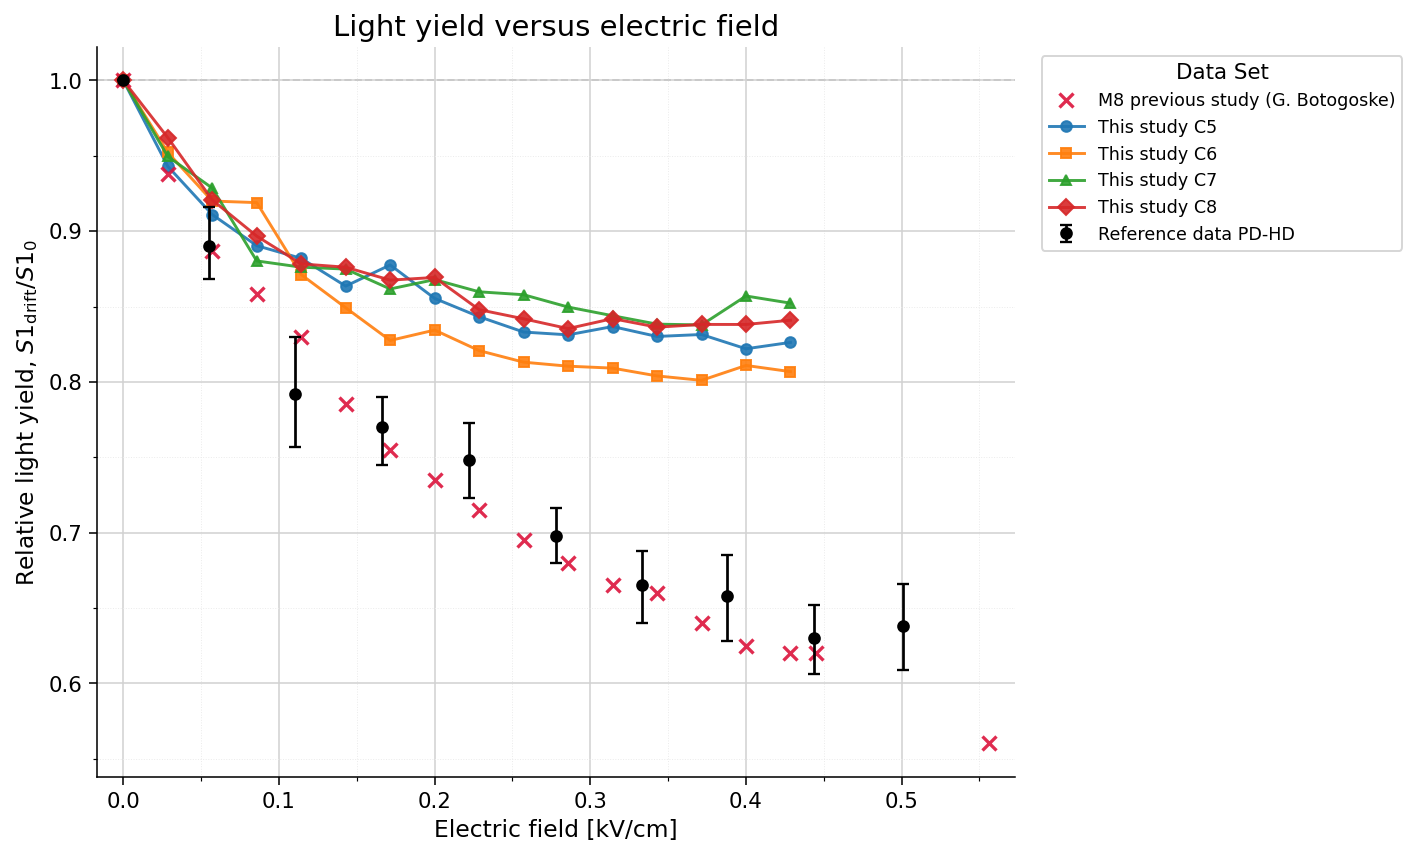

In [37]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from iminuit import Minuit
from iminuit.cost import LeastSquares

study_results = []

for study in study_config_top_to_middle:
    efields, means = calculate_study_XA(
        study["csv_suffix"],
        study["channels"],
    )
    study_results.append({
        **study,
        "efields": efields,
        "means": means,
    })
    print(f"{study['label']}: {len(means)} electric-field points")


colors = plt.colormaps["tab10"].colors
markers = ["o", "s", "^", "D", "P", "v", "<", ">"]


with plt.rc_context({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 15,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
}):
    fig, ax = plt.subplots(
        figsize=(10, 6),
        dpi=140,
        constrained_layout=True,
    )

    # Previous study
    ax.plot(
        efield_previous,
        relative_s1_previous,
        marker="x",
        markersize=7,
        markeredgewidth=1.7,
        linestyle="none",
        color="crimson",
        alpha=0.9,
        label="M8 previous study (G. Botogoske)",
        zorder=4,
    )

    # Current studies
    for index, study in enumerate(study_results):
        ax.plot(
            study["efields"],
            study["means"],
            marker=markers[index % len(markers)],
            markersize=5.5,
            #linewidth=1.3,
            #linestyle="-",
            color=colors[index % len(colors)],
            alpha=0.9,
            label=study["label"],
            #zorder=3,
        )

    # Reference data
    ax.errorbar(
        E,
        PD_HD_result,
        yerr=[PD_HD_err_low, PD_HD_err_high],
        fmt="o",
        markersize=5.5,
        color="black",
        ecolor="black",
        elinewidth=1.4,
        capsize=3,
        capthick=1.2,
        label="Reference data PD-HD",
        zorder=5,
    )

    # Reference line at zero-field normalization
    ax.axhline(
        1.0,
        color="0.45",
        linewidth=1,
        linestyle="--",
        alpha=0.6,
        zorder=1,
    )

    ax.set(
        title="Light yield versus electric field",
        xlabel=r"Electric field [kV/cm]",
        ylabel=r"Relative light yield, $S1_{\mathrm{drift}}/S1_0$",
    )

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.grid(
        which="major",
        color="0.82",
        linewidth=0.8,
    )
    ax.grid(
        which="minor",
        color="0.92",
        linewidth=0.5,
        linestyle=":",
    )

    ax.tick_params(direction="out", length=4)
    ax.margins(x=0.03, y=0.05)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=True,
        title="Data Set",
    )

    plt.show()

In [46]:
def LArQL(E_D,B_1,k_e,B_2,E_0):
    return 1 - ( B_1/ (1+ (k_e/np.abs(E_D)) ) ) +B_2*(1-np.e**-(np.abs(E_D)/E_0))

def Birks(A, E,B):
    return 1.0 - A * E / (1.0 + B * E)


In [47]:
study_results = []

for config in study_configs_datasets:
    efields, means, sems = calculate_study_mean_all(
        config["datasets"]
    )
    study_results.append({
        **config,
        "efields": efields,
        "means": means,
        "sems": sems,
    })
    print(f"{config["label"]}: {len(means)} electric-field points")


colors = plt.colormaps["tab10"].colors
markers = ["o", "s", "^", "D", "P", "v", "<", ">"]

print(study_results[0]["efields"])


cost = LeastSquares(
    study_results[0]["efields"],
    study_results[0]["means"],
    study_results[0]["sems"],
    LArQL
)

m = Minuit(cost, 
           B_1 = 0.1,
           B_2 = 0.5,
           E_0 = 0.1,
           k_e = 0.1)


m.interactive()
m.migrad()
m.hesse()




This study — mean all channels for M5, M6 and M8 : 17 electric-field points
[0.       0.028571 0.057143 0.085714 0.114286 0.142857 0.171429 0.2
 0.228571 0.257143 0.285714 0.314286 0.342857 0.371429 0.4      0.428571
 0.444857]


ModuleNotFoundError: No module named 'ipywidgets'

Please install ipywidgets, IPython, and matplotlib to enable interactive

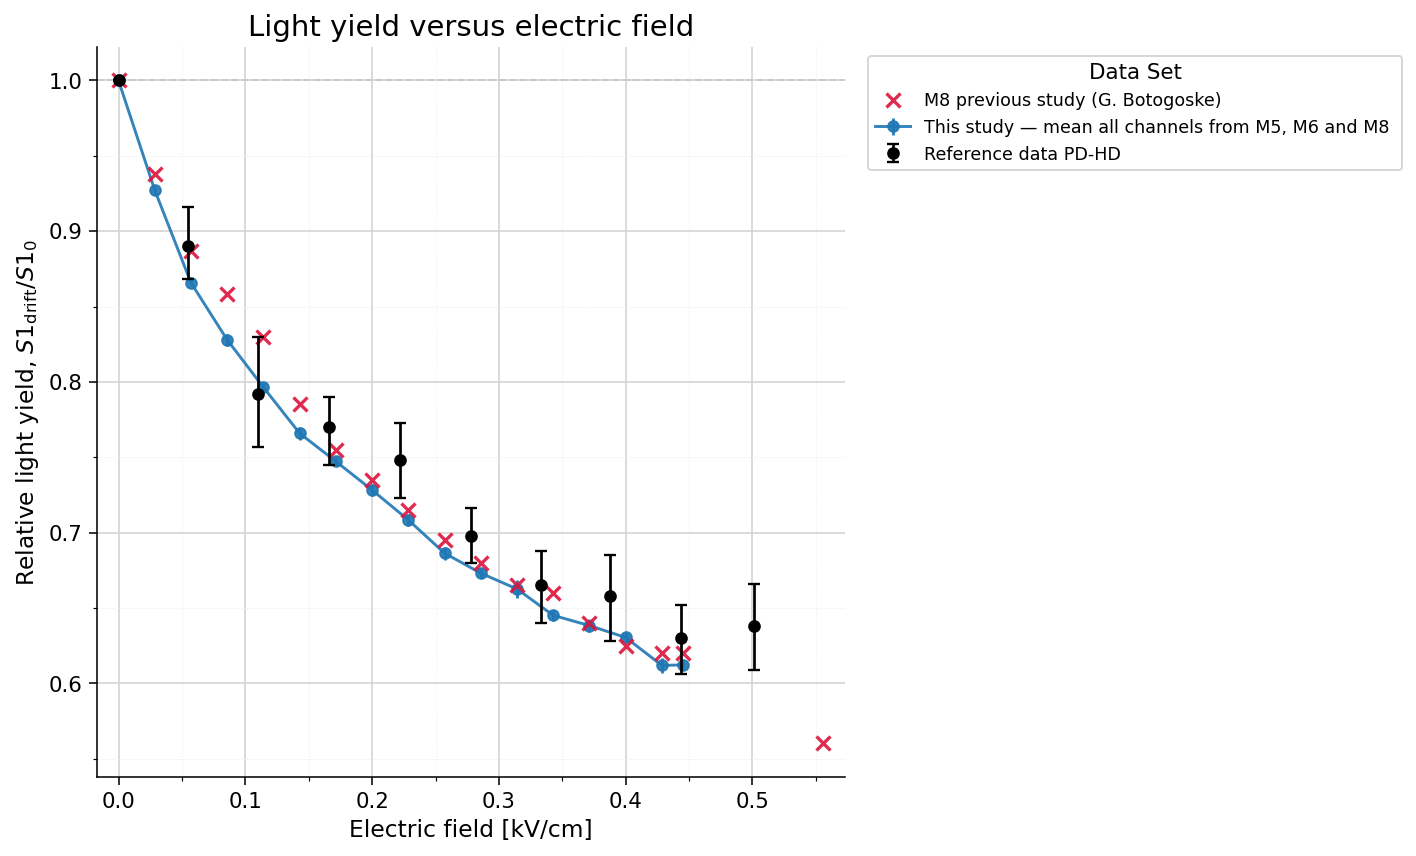

In [44]:
with plt.rc_context({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 15,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
}):
    fig, ax = plt.subplots(
        figsize=(10, 6),
        dpi=140,
        constrained_layout=True,
    )

    # Previous study
    ax.plot(
        efield_previous,
        relative_s1_previous,
        marker="x",
        markersize=7,
        markeredgewidth=1.7,
        linestyle="none",
        color="crimson",
        alpha=0.9,
        label="M8 previous study (G. Botogoske)",
        zorder=4,
    )

    # Current studies
    for index, study in enumerate(study_results):
        ax.errorbar(
            study["efields"],
            study["means"],
            yerr=study["sems"],
            marker=markers[index % len(markers)],
            markersize=5.5,
            #linewidth=1.3,
            #linestyle="-",
            color=colors[index % len(colors)],
            alpha=0.9,
            label=study["label"],
            #zorder=3,
        )

    # Reference data
    ax.errorbar(
        E,
        PD_HD_result,
        yerr=[PD_HD_err_low, PD_HD_err_high],
        fmt="o",
        markersize=5.5,
        color="black",
        ecolor="black",
        elinewidth=1.4,
        capsize=3,
        capthick=1.2,
        label="Reference data PD-HD",
        zorder=5,
    )

    # Reference line at zero-field normalization
    ax.axhline(
        1.0,
        color="0.45",
        linewidth=1,
        linestyle="--",
        alpha=0.6,
        zorder=1,
    )

    ax.set(
        title="Light yield versus electric field",
        xlabel=r"Electric field [kV/cm]",
        ylabel=r"Relative light yield, $S1_{\mathrm{drift}}/S1_0$",
    )

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.grid(
        which="major",
        color="0.82",
        linewidth=0.8,
    )
    ax.grid(
        which="minor",
        color="0.92",
        linewidth=0.5,
        linestyle=":",
    )

    ax.tick_params(direction="out", length=4)
    ax.margins(x=0.03, y=0.05)

    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=True,
        title="Data Set",
    )

    plt.show()